# Conclusiones: Comparativa Titanic vs Sewol
**TFE — Supervivencia en Desastres Marítimos**

Este notebook parte del dataset combinado generado en `TFE_Comparativa_Sewol.ipynb` y construye la tabla comparativa final y el análisis de protocolos de evacuación.

## Paso 1 — Carga del dataset combinado

Cargamos el CSV generado en el notebook anterior. Este fichero contiene los pasajeros y tripulantes de los dos desastres con las columnas normalizadas: `disaster`, `gender`, `age`, `survived`, `role`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

combined = pd.read_csv('../output/comparativa_titanic_sewol.csv')

print('Dataset combinat - shape:', combined.shape)
print()
display(combined.head(10))


Dataset combinat - shape: (1367, 5)



,disaster,gender,age,survived,role
0,titanic,male,22.0,0.0,passenger
1,titanic,female,38.0,1.0,passenger
2,titanic,female,26.0,1.0,passenger
3,titanic,female,35.0,1.0,passenger
4,titanic,male,35.0,0.0,passenger
5,titanic,male,26.0,0.0,passenger
6,titanic,male,54.0,0.0,passenger
7,titanic,male,2.0,0.0,passenger
8,titanic,female,27.0,1.0,passenger
9,titanic,female,14.0,1.0,passenger


## Paso 2 — Tabla comparativa final

Calculamos los indicadores clave de los dos desastres en una sola tabla. Esta es la pieza central de las conclusiones del TFE: permite ver de un vistazo cómo difirieron los dos desastres en cada variable.

Los indicadores que calculamos son:
- Tasa global de supervivencia (solo pasajeros)
- Tasa de supervivencia de mujeres pasajeras
- Tasa de supervivencia de hombres pasajeros
- Ratio mujeres/hombres (cuántas veces más sobrevivieron las mujeres)
- Tasa de supervivencia de adolescentes (13-19 años)
- Tasa de supervivencia por franja de edad
- Edad media de los supervivientes
- Edad media de los no supervivientes

In [14]:
passengers = combined[combined['role'] == 'passenger'].copy()

results = {}

for disaster in ['titanic', 'sewol']:
    d = passengers[passengers['disaster'] == disaster]

    # Taxes generals
    total_rate   = d['survived'].mean() * 100
    female_rate  = d[d['gender'] == 'female']['survived'].mean() * 100
    male_rate    = d[d['gender'] == 'male']['survived'].mean() * 100
    ratio        = female_rate / male_rate
    teen_rate    = d[(d['age'] >= 13) & (d['age'] < 20)]['survived'].mean() * 100
    age_survived = d[d['survived'] == 1]['age'].mean()
    age_dead     = d[d['survived'] == 0]['age'].mean()

    # Taxes per franja d'edat
    bins      = [0, 13, 20, 40, 60, 100]
    age_labels = ['Nen (0-12)', 'Adolescent (13-19)', 'Adult jove (20-39)', 'Adult (40-59)', 'Gran (60+)']
    d = d.copy()
    d['age_group'] = pd.cut(d['age'], bins=bins, labels=age_labels, right=False)
    age_rates = {
        f'Supervivència {g} (%)': round(d[d['age_group'] == g]['survived'].mean() * 100, 1)
        for g in age_labels
    }

    results[disaster] = {
        'Taxa global (%)':               round(total_rate, 1),
        'Supervivencia dones (%)':        round(female_rate, 1),
        'Supervivencia homes (%)':        round(male_rate, 1),
        'Ratio dones/homes':              round(ratio, 2),
        **age_rates,
        'Edat mitjana supervivents':      round(age_survived, 1),
        'Edat mitjana no supervivents':   round(age_dead, 1),
    }

comparison = pd.DataFrame(results).rename(columns={'titanic': 'Titanic (1912)', 'sewol': 'Sewol (2014)'})

print('Taula comparativa final:')
print()
display(comparison)
print()
print(comparison.to_string())

Taula comparativa final:



,Titanic (1912),Sewol (2014)
Taxa global (%),38.40,33.60
Supervivencia dones (%),74.20,29.10
Supervivencia homes (%),18.90,36.80
Ratio dones/homes,3.93,0.79
Supervivència Nen (0-12) (%),57.50,50.00
Supervivència Adolescent (13-19) (%),45.30,23.90
Supervivència Adult jove (20-39) (%),33.70,52.20
Supervivència Adult (40-59) (%),40.40,78.20
Supervivència Gran (60+) (%),26.90,46.20
Edat mitjana supervivents,28.20,31.40



                                      Titanic (1912)  Sewol (2014)
Taxa global (%)                                38.40         33.60
Supervivencia dones (%)                        74.20         29.10
Supervivencia homes (%)                        18.90         36.80
Ratio dones/homes                               3.93          0.79
Supervivència Nen (0-12) (%)                   57.50         50.00
Supervivència Adolescent (13-19) (%)           45.30         23.90
Supervivència Adult jove (20-39) (%)           33.70         52.20
Supervivència Adult (40-59) (%)                40.40         78.20
Supervivència Gran (60+) (%)                   26.90         46.20
Edat mitjana supervivents                      28.20         31.40
Edat mitjana no supervivents                   29.80         20.80


### 2.1 Alternativas visuales para la tabla comparativa

Presentamos dos opciones visuales para mostrar los mismos indicadores. Elige la que más te guste para la memoria y la presentación.

#### Opción 1 — Tabla con colores (verde = mejor, rojo = peor)

In [15]:
def color_best(row):
    # Per al ratio dones/homes, el valor més alt no és necessàriament "millor"
    # Per a taxes de supervivència, verd = més alt, vermell = més baix
    titanic_val = row['Titanic (1912)']
    sewol_val   = row['Sewol (2014)']
    if titanic_val > sewol_val:
        return ['background-color: #c8e6c9; font-weight: bold',
                'background-color: #ffcdd2']
    elif sewol_val > titanic_val:
        return ['background-color: #ffcdd2',
                'background-color: #c8e6c9; font-weight: bold']
    else:
        return ['', '']

styled = comparison.style.apply(color_best, axis=1).set_caption('Taula comparativa: Titanic vs Sewol')
display(styled)

,Titanic (1912),Sewol (2014)
Taxa global (%),38.400000,33.600000
Supervivencia dones (%),74.200000,29.100000
Supervivencia homes (%),18.900000,36.800000
Ratio dones/homes,3.930000,0.790000
Supervivència Nen (0-12) (%),57.500000,50.000000
Supervivència Adolescent (13-19) (%),45.300000,23.900000
Supervivència Adult jove (20-39) (%),33.700000,52.200000
Supervivència Adult (40-59) (%),40.400000,78.200000
Supervivència Gran (60+) (%),26.900000,46.200000
Edat mitjana supervivents,28.200000,31.400000


#### Opción 2 — Barras horizontales comparativas

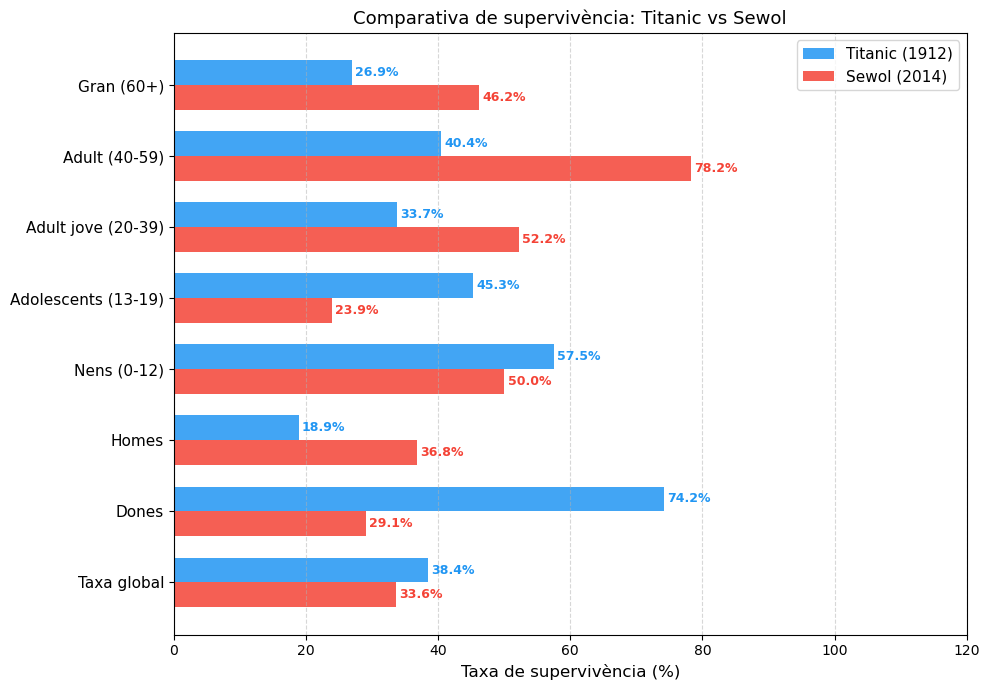

Gràfic guardat a output/barres_comparativa_titanic_sewol.png


In [17]:
indicadors = [
    'Taxa global (%)',
    'Supervivencia dones (%)',
    'Supervivencia homes (%)',
    'Supervivència Nen (0-12) (%)',
    'Supervivència Adolescent (13-19) (%)',
    'Supervivència Adult jove (20-39) (%)',
    'Supervivència Adult (40-59) (%)',
    'Supervivència Gran (60+) (%)',
]
etiquetes = [
    'Taxa global',
    'Dones',
    'Homes',
    'Nens (0-12)',
    'Adolescents (13-19)',
    'Adult jove (20-39)',
    'Adult (40-59)',
    'Gran (60+)',
]
titanic_vals = [results['titanic'][i] for i in indicadors]
sewol_vals   = [results['sewol'][i]   for i in indicadors]

y      = np.arange(len(etiquetes))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 7))
bars1 = ax.barh(y + height/2, titanic_vals, height, label='Titanic (1912)', color='#2196F3', alpha=0.85)
bars2 = ax.barh(y - height/2, sewol_vals,   height, label='Sewol (2014)',   color='#F44336', alpha=0.85)

for bar, val in zip(bars1, titanic_vals):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9, fontweight='bold', color='#2196F3')
for bar, val in zip(bars2, sewol_vals):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9, fontweight='bold', color='#F44336')

ax.set_xlabel('Taxa de supervivència (%)', fontsize=12)
ax.set_title('Comparativa de supervivència: Titanic vs Sewol', fontsize=13)
ax.set_yticks(y)
ax.set_yticklabels(etiquetes, fontsize=11)
ax.set_xlim(0, 120)
ax.legend(fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../output/barres_comparativa_titanic_sewol.png', dpi=150)
plt.show()
print('Gràfic guardat a output/barres_comparativa_titanic_sewol.png')

In [18]:
print('='*60)
print('RESUM DE DADES PER A L\'INFORME')
print('='*60)

print('\n--- TAULA COMPARATIVA ---')
print(comparison.to_string())

print('\n--- PROTOCOL: DONES VS HOMES ---')
for disaster in ['titanic', 'sewol']:
    d = passengers[passengers['disaster'] == disaster]
    female_rate = d[d['gender'] == 'female']['survived'].mean() * 100
    male_rate   = d[d['gender'] == 'male']['survived'].mean() * 100
    ratio       = female_rate / male_rate
    n_female    = len(d[d['gender'] == 'female'])
    n_male      = len(d[d['gender'] == 'male'])
    print(f'{disaster.upper()}: dones {female_rate:.1f}% (n={n_female}) | homes {male_rate:.1f}% (n={n_male}) | ratio {ratio:.2f}x')

print('\n--- PROTOCOL: NENS VS ADULTS ---')
for disaster in ['titanic', 'sewol']:
    d = passengers[passengers['disaster'] == disaster]
    children_rate = d[d['age'] < 13]['survived'].mean() * 100
    adults_rate   = d[d['age'] >= 13]['survived'].mean() * 100
    n_children    = len(d[d['age'] < 13])
    n_adults      = len(d[d['age'] >= 13])
    ratio         = children_rate / adults_rate if adults_rate > 0 else 0
    print(f'{disaster.upper()}: nens {children_rate:.1f}% (n={n_children}) | adults {adults_rate:.1f}% (n={n_adults}) | ratio {ratio:.2f}x')

print('\n--- TOTALS ---')
for disaster in ['titanic', 'sewol']:
    d = passengers[passengers['disaster'] == disaster]
    print(f'{disaster.upper()}: total={len(d)} | supervivents={int(d["survived"].sum())} | taxa={d["survived"].mean()*100:.1f}%')

RESUM DE DADES PER A L'INFORME

--- TAULA COMPARATIVA ---
                                      Titanic (1912)  Sewol (2014)
Taxa global (%)                                38.40         33.60
Supervivencia dones (%)                        74.20         29.10
Supervivencia homes (%)                        18.90         36.80
Ratio dones/homes                               3.93          0.79
Supervivència Nen (0-12) (%)                   57.50         50.00
Supervivència Adolescent (13-19) (%)           45.30         23.90
Supervivència Adult jove (20-39) (%)           33.70         52.20
Supervivència Adult (40-59) (%)                40.40         78.20
Supervivència Gran (60+) (%)                   26.90         46.20
Edat mitjana supervivents                      28.20         31.40
Edat mitjana no supervivents                   29.80         20.80

--- PROTOCOL: DONES VS HOMES ---
TITANIC: dones 74.2% (n=314) | homes 18.9% (n=577) | ratio 3.93x
SEWOL: dones 29.1% (n=182) | homes 36.8

## Paso 3 — Análisis del protocolo de evacuación

El protocolo 'mujeres y niños primero' tiene dos dimensiones: el género y la edad. Analizamos las dos por separado:

- **3.1 Mujeres vs hombres**: si las mujeres sobrevivieron más que los hombres, el protocolo de género se aplicó
- **3.2 Niños vs adultos**: si los niños sobrevivieron más que los adultos, el protocolo de edad se aplicó

Calculamos el ratio en cada caso para los dos desastres y los visualizamos.

### 3.1 Mujeres vs hombres

Calculamos el ratio de supervivencia mujeres/hombres en cada desastre. Un ratio > 1 indica que las mujeres sobrevivieron más que los hombres (protocolo aplicado). Un ratio < 1 indica que los hombres sobrevivieron más.

Ratio dones/homes Titanic: 3.93x
Ratio dones/homes Sewol:   0.79x

Al Titanic, ser dona multiplicava per 3.93x la probabilitat de sobreviure respecte a ser home.
Al Sewol, el patro s'inverteix: els homes van sobreviure mes que les dones (ratio 0.79x).


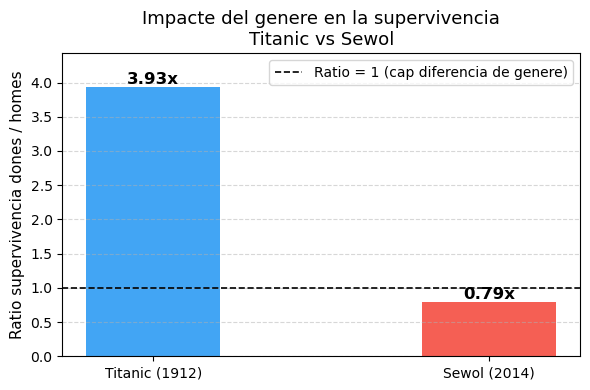

Grafic guardat a output/ratio_genere_titanic_sewol.png


In [3]:
titanic_ratio = results['titanic']['Ratio dones/homes']
sewol_ratio   = results['sewol']['Ratio dones/homes']

print(f'Ratio dones/homes Titanic: {titanic_ratio}x')
print(f'Ratio dones/homes Sewol:   {sewol_ratio}x')
print()

if titanic_ratio > 1:
    print(f'Al Titanic, ser dona multiplicava per {titanic_ratio}x la probabilitat de sobreviure respecte a ser home.')
if sewol_ratio < 1:
    print(f'Al Sewol, el patro s\'inverteix: els homes van sobreviure mes que les dones (ratio {sewol_ratio}x).')

# Grafic del ratio
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Titanic (1912)', 'Sewol (2014)'], [titanic_ratio, sewol_ratio],
               color=['#2196F3', '#F44336'], alpha=0.85, width=0.4)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, label='Ratio = 1 (cap diferencia de genere)')
for bar, val in zip(bars, [titanic_ratio, sewol_ratio]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val}x', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Ratio supervivencia dones / homes', fontsize=11)
ax.set_title('Impacte del genere en la supervivencia\nTitanic vs Sewol', fontsize=13)
ax.set_ylim(0, max(titanic_ratio, sewol_ratio) + 0.5)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../output/ratio_genere_titanic_sewol.png', dpi=150)
plt.show()
print('Grafic guardat a output/ratio_genere_titanic_sewol.png')


### 3.2 Niños vs adultos

Calculamos la tasa de supervivencia de los niños (0-12 años) respecto a los adultos (13+) en cada desastre. Si los niños sobrevivieron más, el protocolo 'niños primero' se aplicó.

**Nota metodológica:** El Sewol solo cuenta con 4 niños (0-12 años) en la muestra. Este tamaño de muestra es insuficiente para extraer conclusiones estadísticamente significativas para este grupo en el Sewol. El resultado se incluye por completitud, pero no puede interpretarse como evidencia del protocolo de evacuación para este desastre.

TITANIC
  Nens (0-12):  57.5%  (n=73)
  Adults (13+): 36.7%
  Ratio nens/adults: 1.57x

SEWOL
  Nens (0-12):  50.0%  (n=4)
  Adults (13+): 33.5%
  Ratio nens/adults: 1.49x



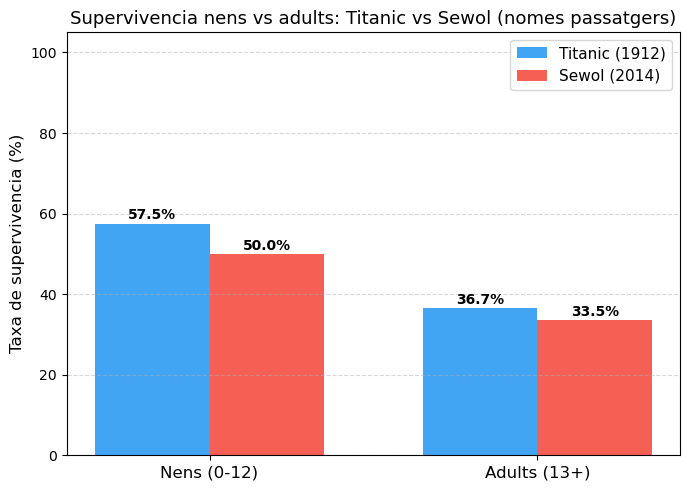

Grafic guardat a output/ratio_nens_adults_titanic_sewol.png


In [5]:
for disaster in ['titanic', 'sewol']:
    d = passengers[passengers['disaster'] == disaster]
    children_rate = d[d['age'] < 13]['survived'].mean() * 100
    adults_rate   = d[d['age'] >= 13]['survived'].mean() * 100
    n_children    = len(d[d['age'] < 13])
    ratio_children = children_rate / adults_rate if adults_rate > 0 else 0
    print(f'{disaster.upper()}')
    print(f'  Nens (0-12):  {children_rate:.1f}%  (n={n_children})')
    print(f'  Adults (13+): {adults_rate:.1f}%')
    print(f'  Ratio nens/adults: {ratio_children:.2f}x')
    print()

# Grafic comparatiu
categories = ['Nens (0-12)', 'Adults (13+)']
titanic_rates = [
    passengers[(passengers['disaster'] == 'titanic') & (passengers['age'] < 13)]['survived'].mean() * 100,
    passengers[(passengers['disaster'] == 'titanic') & (passengers['age'] >= 13)]['survived'].mean() * 100
]
sewol_rates = [
    passengers[(passengers['disaster'] == 'sewol') & (passengers['age'] < 13)]['survived'].mean() * 100,
    passengers[(passengers['disaster'] == 'sewol') & (passengers['age'] >= 13)]['survived'].mean() * 100
]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, titanic_rates, width, label='Titanic (1912)', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, sewol_rates,   width, label='Sewol (2014)',   color='#F44336', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Taxa de supervivencia (%)', fontsize=12)
ax.set_title('Supervivencia nens vs adults: Titanic vs Sewol (nomes passatgers)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../output/ratio_nens_adults_titanic_sewol.png', dpi=150)
plt.show()
print('Grafic guardat a output/ratio_nens_adults_titanic_sewol.png')